<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_1_Classification_Basics/18_1_4_ROC_AUC_Threshold_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification: Part 4
## ROC Curves and Threshold Tuning

Author: Brad Sheese

---

## Introduction
When we evaluate a model, we often get stuck on a single set of numbers. However, changing the decision threshold, the cutoff where we classify an observation as "1" instead of "0", can drastically shift our model's performance. This creates a dilemma: if Model A is better at one threshold but Model B is better at another, which one is truly the superior classifier?

In this notebook, we move beyond single points to evaluate the ROC (Receiver Operating Characteristic) curve and its summary metric, the AUC (Area Under the Curve). These tools allow us to visualize and measure a model's performance across all possible thresholds at once.

Once we have the right model, we will move from theory to practice by:

- Using Youden's J statistic to identify a mathematically "optimal" balance.

- Tuning thresholds based on real-world business costs, where the price of a False Positive rarely equals the price of a False Negative.

### Learning Objectives
By the end of this notebook, you will be able to:
1. Interpret ROC curves and understand the trade-off between TPR and FPR.
2. Use AUC to compare the performance of different models.
3. Understand why precision-recall curves are sometimes better than ROC curves for imbalanced data.
4. Calculate Youden's J to find the "goldilocks" decision boundary.
5. Pick a threshold based on real business costs, not just mathematical optimality.

## Section 1: Setup and Data Loading

As before, we'll train our balanced XGBoost model on the South German Credit data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import roc_curve, auc, precision_recall_curve, recall_score, precision_score, average_precision_score
from sklearn.metrics import confusion_matrix, classification_report

data = fetch_openml(name='credit-g', version=1, as_frame=True)
df = data.frame

y = (df['class'] == 'bad').astype(int)
X = df.drop(columns=['class'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Omitted step: We do NOT use scale_pos_weight here because we are going to
# tune the decision threshold instead. You do not do both.

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42,
    enable_categorical=True,
    tree_method='hist'
)
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
print("Model ready for evaluation.")

> **Simplification for this notebook:** The comment above omits `scale_pos_weight` because, *for this notebook*, we treat threshold tuning as the sole imbalance correction — keeping the two levers separate makes each one easier to study in isolation. In practice you can combine them: using `scale_pos_weight` (or a custom cost-weighted objective, as shown in Notebook 6) shifts the model's decision boundary during training, while threshold tuning shifts it afterward. Notebook 6 demonstrates exactly that combination.

## Section 2: The ROC Curve (TPR vs. FPR)

The ROC curve plots two metrics against each other as we slide our threshold from 0 to 1:

1.  True Positive Rate (TPR): Same as recall. "Of all defaults, how many did we catch?"
2.  False Positive Rate (FPR): "Of all good customers, how many did we wrongly flag?"

### What to Look For:
- A perfect model would hug the top-left corner (TPR=1, FPR=0): catch all defaulters, flag zero good customers.
- A random model would be a diagonal line (the chance line): no better than flipping a coin.
- The more "arched" the curve is toward the top-left, the better the model is at separating the two classes.

### What AUC Actually Means

The AUC (Area Under the Curve) is one of the most widely used threshold-independent metrics for model comparison. It represents the probability that the model will rank a randomly chosen positive instance higher than a randomly chosen negative one.

Concrete example: If you randomly pick one defaulter and one good customer from the test set, an AUC of 0.80 means the model will correctly assign a higher default probability to the defaulter 80% of the time. An AUC of 0.50 means the model is no better than a coin flip.

### A Note on Out-of-Fold (OOF) Predictions

Throughout this notebook, we optimize thresholds using **out-of-fold (OOF) predictions** on the training set rather than the test set. Understanding why this matters is important before we proceed.

The test set is our final, untouched benchmark. If we use it to choose a threshold, we are making a modeling decision using test labels — which means the evaluation is no longer honest. The threshold would be optimized to those specific test samples, not to genuinely new data.

Out-of-fold predictions solve this by running cross-validation on the training data:
1. Split the training set into 5 folds.
2. Train the model on 4 folds and predict on the held-out fold.
3. Repeat until every training sample has been predicted by a model it was never trained on.

The result is a full set of training-set probabilities where each prediction was made on data the model had not seen. These OOF probabilities simulate real generalization and are safe to use for threshold selection. The test set is then reserved for final evaluation only — touched once, at the very end.

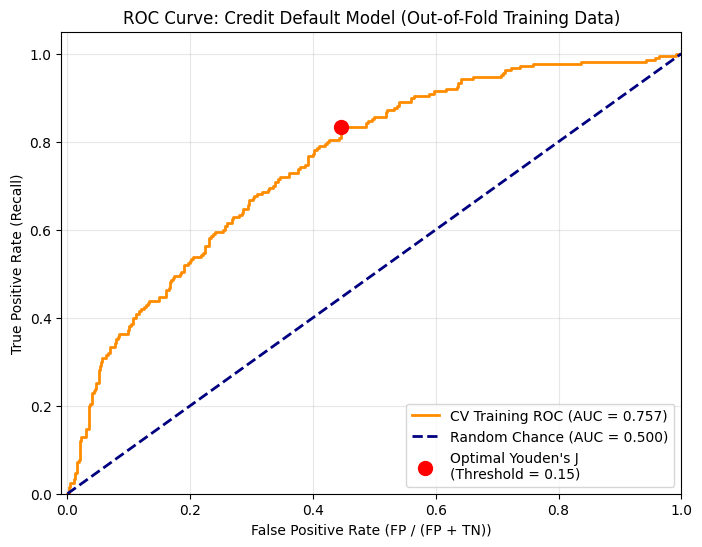

Out-of-Fold Training AUC = 0.757
Optimal Threshold (Youden's J) = 0.151

Interpretation: If you randomly pick one defaulter
and one good customer, the model correctly ranks the
defaulter as higher-risk 75.7% of the time.


In [ ]:
oof_train_probs = cross_val_predict(model, X_train, y_train, cv=5, method='predict_proba')[:, 1]

# 1. Calculate the ROC curve points using CROSS-VALIDATED TRAINING DATA
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, oof_train_probs)
roc_auc_train = auc(fpr_train, tpr_train)

# 2. Find Youden's J optimal point on the TRAINING data
j_scores = tpr_train - fpr_train
best_idx = np.argmax(j_scores)
best_tpr = tpr_train[best_idx]
best_fpr = fpr_train[best_idx]
optimal_j_threshold = thresholds_train[best_idx]  # Extract the actual threshold!

# 3. Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2,
         label=f'CV Training ROC (AUC = {roc_auc_train:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Random Chance (AUC = 0.500)')
# Mark the Youden's J optimal point and display the threshold
plt.scatter([best_fpr], [best_tpr], color='red', s=100, zorder=5,
            label=f"Optimal Youden's J\n(Threshold = {optimal_j_threshold:.2f})")

plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FP / (FP + TN))')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve: Credit Default Model (Out-of-Fold Training Data)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Out-of-Fold Training AUC = {roc_auc_train:.3f}")
print(f"Optimal Threshold (Youden's J) = {optimal_j_threshold:.3f}")
print(f"\nInterpretation: If you randomly pick one defaulter")
print(f"and one good customer, the model correctly ranks the")
print(f"defaulter as higher-risk {roc_auc_train*100:.1f}% of the time.")

### Reading the Curve

The red dot marks the Youden's J optimal point — the threshold that maximizes TPR while minimizing FPR. We will discuss this more later in the notebook. Look at where it sits:

- At the far left (low FPR): The model is very conservative. It catches few defaulters but barely flags any good customers.
- At the top (high TPR): The model catches almost all defaulters but also flags many good customers.
- The "knee" of the curve is where you get the most TPR for the least FPR — this is typically close to the Youden's J point.

The AUC printed above describes how well the model separates the two classes across all thresholds. Locate it in the grading scale below.

## Interpreting AUC Scores

The quality labels below are not mathematical laws — they are widely used industry heuristics that help translate an abstract number into a practical grade.

### 1. The Standard Grading Scale

| AUC Score | Quality / Interpretation |
| :--- | :--- |
| **0.50** | **No Skill:** No better than a coin flip. |
| **0.60 – 0.70** | **Poor:** Better than random, but not very useful for high-stakes decisions. |
| **0.70 – 0.80** | **Acceptable:** The model has a solid grasp of the patterns but still makes mistakes. |
| **0.80 – 0.90** | **Excellent:** Strong predictive power; highly reliable for decision-making. |
| **0.90 – 1.00** | **Outstanding:** Rare in real-world messy data (often suggests data leakage). |

### 2. Reading Our Model's Score

The AUC above places our model in the **Acceptable** range. In concrete terms: if you randomly selected one defaulter and one good customer from the test set, the model correctly ranks the defaulter as higher-risk roughly 75% of the time — getting the ordering wrong about 25% of the time.

In finance, even a modest improvement over random guessing can translate to significant savings in bad debt. The exact score will vary depending on the dataset, model parameters, and features — treat it as a starting point to improve, not a final verdict.

### 3. Context Matters

The definition of "acceptable" changes based on the cost of an error:
* **Low Stakes (Netflix Recommendations):** An AUC of 0.70 might be "Excellent" because the cost of a bad movie suggestion is tiny.
* **High Stakes (Cancer Detection):** An AUC of 0.80 might be considered "Poor" because a 20% ranking error rate is too risky when lives are at stake.
* **Finance (Credit Scores):** An Acceptable-range AUC is generally a reasonable baseline because human financial behavior is inherently somewhat unpredictable.

## Section 3: ROC vs. Precision-Recall Curves

While ROC curves are standard, they can be over-optimistic on imbalanced data. Here's why:

- The FPR denominator is all actual negatives (good customers). If you have hundreds of good customers, your FPR stays low even if you have dozens of false positives. The ROC curve looks great because the true negatives overwhelm the false positives in the denominator.

The precision-recall (PR) curve is more "honest" for imbalanced data because it ignores true negatives entirely. Precision only asks: "of the people we flagged, how many were actually bad?" If you flag many good customers, precision drops, regardless of how many true negatives you have.

**A note on data usage:** The ROC curve in Section 2 was computed using out-of-fold training probabilities — that is the correct setup when using a curve for *threshold selection*, since we cannot make modeling decisions using the test set. The PR curve below is computed on the *test set* for *evaluation only* — we are not choosing a threshold from it here, just assessing how the model's precision-recall trade-off looks on held-out data.

In the next notebook (Notebook 5), we will use the PR curve directly for threshold optimization using a metric called the **F-Beta score**, which extends F1 to let you explicitly weight recall more heavily than precision. That approach follows the same OOF-on-training principle to keep the test set clean.

Let's compare the ROC and PR perspectives on this model.

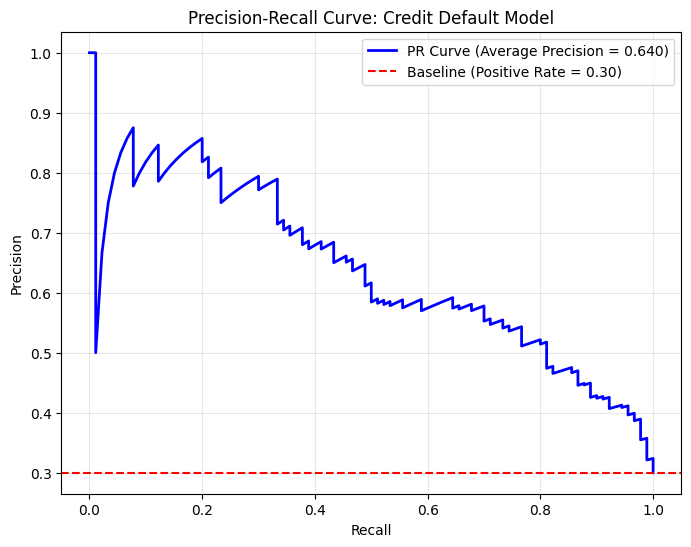

Average Precision = 0.640
Baseline (random guessing precision) = 0.300


In [ ]:
from sklearn.metrics import average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_proba)

avg_precision = average_precision_score(y_test, y_proba)
pos_rate = y_test.mean()

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR Curve (Average Precision = {avg_precision:.3f})')
plt.axhline(y=pos_rate, color='red', linestyle='--', label=f'Baseline (Positive Rate = {pos_rate:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Credit Default Model')
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Average Precision = {avg_precision:.3f}")
print(f"Baseline (random guessing precision) = {pos_rate:.3f}")

### Reading the PR Curve

The red dashed line shows the baseline precision you'd get from random guessing. For a classifier that simply predicts the positive class with the same probability as the overall positive rate in the dataset:
- If ~30% of applicants are defaulters, a random classifier guessing "defaulter" with 30% probability would achieve ~30% precision.
- Any useful model must stay well above this baseline. The further the PR curve is from this line, the better the model performs on the minority class.

Notice how the PR curve behaves at the extremes:
- At high recall (right side): The model catches most defaulters, but precision drops — many false alarms dilute the positive predictions.
- At high precision (left side): When the model is very selective, precision is high but recall is low. It only flags the most obvious defaulters.

If the PR curve hugs close to the baseline, your model isn't doing much better than random guessing for the minority class, even if the ROC curve looks impressive.

### A Note on Imbalance Severity

Our dataset has a moderate 70/30 class split. Compare the ROC AUC and PR AUC values printed by the code in Sections 2 and 3 — you will see a noticeable gap between them. In truly skewed datasets (e.g., 99/1 fraud detection), this gap becomes dramatic: the ROC AUC can be near 0.99 while the PR AUC reveals the model is nearly useless at identifying positives. The more imbalanced the data, the more the PR curve matters as an evaluation tool.

### Looking Ahead: Optimizing Against the PR Curve

In this notebook we optimize thresholds using Youden's J, which is derived from the ROC curve and treats false positives and false negatives as equally costly. In the next notebook (Notebook 5), we will optimize thresholds *directly against the PR curve* using the **F-Beta score** — a generalization of F1 that lets you dial in how much more you care about recall than precision. For problems like fraud detection, where missing a case is far more expensive than a false alarm, F-Beta tuned against the PR curve is often the more appropriate choice.

## Section 4: Picking a Single Point for the Decision

We've looked at two types of curves to get a sense of the how our model is doing globally. Now we are going to shift gears to try to find a single optimal decision point.


One common method is Youden's J statistic. It finds the mathematically optimal threshold that maximizes the distance between the ROC curve and the random chance line:

$$J = TPR - FPR$$

This finds the threshold that gives you the most "bang for your buck", maximizing detections while minimizing false alarms. It treats both types of error as equally costly, which is a useful starting point but rarely reflects real-world business priorities.

In [ ]:
# oof_train_probs, fpr_train, tpr_train, j_scores, best_idx, and optimal_j_threshold
# were all computed in Section 2 — reused here without recomputing.
best_threshold = optimal_j_threshold

print(f"--- Youden's J Results (Optimized on Training OOF) ---")
print(f"Best Threshold: {best_threshold:.3f}")
print(f"Max J-Score on Train: {j_scores[best_idx]:.3f}")

# Evaluate this threshold on the held-out test set
y_test_preds = (y_proba >= best_threshold).astype(int)
test_tpr = recall_score(y_test, y_test_preds)
test_fpr = ((y_test_preds == 1) & (y_test == 0)).sum() / (y_test == 0).sum()

print(f"\n--- Performance on Test Set using Youden's J threshold ---")
print(f"TPR (Recall): {test_tpr:.3f}")
print(f"FPR:          {test_fpr:.3f}")

# Compare to the default 0.5 threshold
y_default = (y_proba >= 0.5).astype(int)
default_tpr = recall_score(y_test, y_default)
default_fpr = ((y_default == 1) & (y_test == 0)).sum() / (y_test == 0).sum()
print(f"\n--- For Comparison: Default Threshold (0.5) ---")
print(f"TPR (Recall): {default_tpr:.3f}")
print(f"FPR:          {default_fpr:.3f}")

In [ ]:
# Business cost assumptions — defined as named constants so they are easy to
# update and consistently applied across all threshold comparisons below.
COST_FP = 500    # Wrongly denying a good customer's loan: lost interest income
COST_FN = 5000   # Approving a loan that defaults: lost principal

print(f"Cost assumptions:")
print(f"  False Positive (FP): ${COST_FP:,} — lost interest income from a wrongly denied loan")
print(f"  False Negative (FN): ${COST_FN:,} — lost principal from an approved loan that defaults")
print(f"  A missed default costs {COST_FN // COST_FP}x more than a false alarm")

## Section 5: Business Cost Sensitivity

While Youden's J is mathematically optimal, it assumes that a false positive and a false negative have equal cost. In the real world, they rarely do.

For this analysis we assume:
- A **false positive** (wrongly denying a good customer's loan) costs the bank in lost interest income.
- A **false negative** (approving a loan that defaults) costs the bank the full principal amount lent.

The specific dollar values are defined as named constants in the cell above so they are easy to adjust and consistently applied across all threshold comparisons. Using named constants rather than hardcoded numbers buried inside functions makes the cost assumptions transparent and the analysis easy to update.

In [ ]:
# =====================================================================
# STEP 1: Find the Optimal Threshold using ONLY Training Data
# =====================================================================
# oof_train_probs is already available from Section 2 — no need to recompute.

def calculate_expected_cost_per_applicant(y_true, y_prob, threshold):
    """Calculates the average expected business cost per loan applicant."""
    y_pred = (y_prob >= threshold).astype(int)
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    return ((fp * COST_FP) + (fn * COST_FN)) / len(y_true)

# Sweep thresholds from 0.01 to 0.99 and evaluate cost on OOF training probabilities
thresholds = np.linspace(0.01, 0.99, 100)
train_costs_per_applicant = []

for t in thresholds:
    cost = calculate_expected_cost_per_applicant(y_train, oof_train_probs, t)
    train_costs_per_applicant.append(cost)

# Find the threshold with the lowest expected cost
optimal_idx = np.argmin(train_costs_per_applicant)
optimal_threshold = thresholds[optimal_idx]
lowest_train_cost = train_costs_per_applicant[optimal_idx]

print("--- Threshold Optimization (Training Data Only) ---")
print(f"Optimal Threshold: {optimal_threshold:.2f}")
print(f"Estimated Cost per Applicant: ${lowest_train_cost:.2f}")


# =====================================================================
# STEP 1.5: Visualize the Business-Optimal Threshold (Training Data)
# =====================================================================

plt.figure(figsize=(10, 6))

plt.plot(thresholds, train_costs_per_applicant, color='#1f77b4', linewidth=2.5,
         label='Expected Cost Curve')

plt.axvline(x=optimal_threshold, color='red', linestyle='--', alpha=0.7,
            label=f'Optimal Threshold: {optimal_threshold:.2f}')
plt.scatter([optimal_threshold], [lowest_train_cost], color='red', s=100, zorder=5)

plt.text(optimal_threshold + 0.02, lowest_train_cost,
         f'Min Cost: ${lowest_train_cost:.2f}',
         color='red', fontsize=12, verticalalignment='center')

plt.title('Finding the Optimal Threshold via Expected Cost per Applicant', fontsize=14, fontweight='bold')
plt.xlabel('Decision Threshold (Probability of Default)', fontsize=12)
plt.ylabel('Expected Cost per Applicant ($)', fontsize=12)

ax = plt.gca()
ax.yaxis.set_major_formatter('${x:,.0f}')

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()


# =====================================================================
# STEP 2: Evaluate the Final Model on the Unseen Test Data
# =====================================================================
# Apply the threshold learned from training data to the test set.
# We are NOT re-optimizing on the test set — that would contaminate the evaluation.

final_test_preds = (y_proba >= optimal_threshold).astype(int)
final_test_cost_per_applicant = calculate_expected_cost_per_applicant(y_test, y_proba, optimal_threshold)

print(f"\n--- Final Test Set Performance ---")
print(f"Actual Test Cost per Applicant: ${final_test_cost_per_applicant:.2f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_test_preds))

print("\nClassification Report:")
print(classification_report(y_test, final_test_preds))

### Interpreting the Cost Curve

The cost curve shows the total estimated dollar cost at each threshold. The minimum point is the threshold that saves the bank the most money.

Notice how the cost-optimal threshold differs from both the default 0.5 and Youden's J. This is because the cost curve directly encodes your business priorities: false negatives are 10x more expensive than false positives, so the optimal threshold shifts lower to catch more defaulters, even at the cost of more false alarms.

Youden's J gives you a mathematically sound starting point, but the right threshold depends on your specific cost structure. Always ask: "What does a false positive cost us? What does a false negative cost us?" Then pick the threshold that minimizes total cost.

In [ ]:
# Compare all three threshold strategies on the held-out test set.
# All thresholds were selected using training OOF data above — the test set
# is only touched here, at final evaluation.

strategies = {
    "Default (0.50)": 0.50,
    "Youden's J":     optimal_j_threshold,
    "Cost-Optimal":   optimal_threshold,
}

print(f"{'Strategy':<22} {'Threshold':>10} {'Recall (TPR)':>13} {'FPR':>8} {'Cost/Applicant':>15}")
print("-" * 72)
for name, thresh in strategies.items():
    y_p   = (y_proba >= thresh).astype(int)
    tp    = ((y_p == 1) & (y_test == 1)).sum()
    fp    = ((y_p == 1) & (y_test == 0)).sum()
    fn    = ((y_p == 0) & (y_test == 1)).sum()
    tpr   = tp / (tp + fn)
    fpr_v = fp / (y_test == 0).sum()
    cost  = calculate_expected_cost_per_applicant(y_test, y_proba, thresh)
    print(f"{name:<22} {thresh:>10.3f} {tpr:>13.3f} {fpr_v:>8.3f}  ${cost:>12.2f}")

default_cost = calculate_expected_cost_per_applicant(y_test, y_proba, 0.50)
opt_cost     = calculate_expected_cost_per_applicant(y_test, y_proba, optimal_threshold)
print(f"\nPotential savings vs. default (per 1,000 applicants): ${(default_cost - opt_cost) * 1000:,.0f}")

## Summary

### Comparing the Three Strategies

The comparison table above shows each strategy's actual test-set performance. Key patterns to notice:

- **Default (0.5)** leaves recall low. On this dataset the model rarely produces probabilities above 0.5 for defaults, so the default threshold misses the majority of them — the accuracy paradox in action.
- **Youden's J** maximizes the TPR−FPR gap mathematically, but because it treats both error types as equally costly, it may produce a threshold that does not reflect the actual cost asymmetry of the problem.
- **Cost-Optimal** explicitly encodes that a missed default ($5,000) is ten times more expensive than a false alarm ($500). On datasets with a large cost gap, this approach will outperform Youden's J in dollar terms even if its raw error rates look similar.

**Important:** Youden's J and Cost-Optimal thresholds depend entirely on the dataset and model. Never copy a threshold from one project to another — always compute it from your own training data using the OOF approach above.

---

### Threshold Selection Methods

| Method | Threshold | When to Use | Pros | Cons |
|--------|-----------|-------------|------|------|
| **Default (0.5)** | 0.50 | Quick initial evaluation, balanced datasets | Simple, intuitive | Ignores class imbalance and business costs |
| **Youden's J** | dataset-dependent | Mathematical optimization, equal error costs | Maximizes TPR − FPR, useful starting point | Assumes equal cost of FP and FN; can behave unexpectedly on highly imbalanced data |
| **Cost-Optimal** | dataset-dependent | Real-world business decisions | Minimizes actual monetary losses | Requires honest, accurate cost estimates |

### Evaluation Tools

| Tool | Purpose | Best For |
|------|---------|----------|
| **ROC Curve / AUC** | Measure ranking ability across all thresholds | General model comparison |
| **PR Curve / PR AUC** | Measure performance on the positive (minority) class | Imbalanced datasets where true negatives are abundant |

## Supplemental Materials
- [Stat Quest Video on ROC and AUC](https://www.youtube.com/watch?v=4jRBRDbJemM)